IT25101611_Missing_Data_Handling

RASHMIKA - Individual Preprocessing Component

Technique: Handling Missing Data

Why this technique was needed

Real-world health/lifestyle datasets frequently contain missing values (unanswered survey fields, failed sensor readings, skipped lab tests). Before any encoding, scaling, or modeling step, we must know whether missing values exist, how they are represented (true NaN, duplicate rows, or implausible placeholder values such as o for a physiological measurement), and choose an imputation strategy that will not bias the diabetes-stage prediction task. This notebook documents that full verification-and-handling process for the assigned Diabetes and LifeStyle Dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/Diabetes_and_LifeStyle_Dataset_.csv')
print("Shape:", df.shape)
df.head()

Shape: (97297, 31)


,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


Step 1 - Check for explicit missing values (NaN) per column

In [2]:
print("Missing values report:")
print(df.isnull().sum())
print(" ")
print("Missing values percentage:")
print((df.isnull().sum() / len(df)) * 100)


Missing values report:
Age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting  

In [3]:
print(f"Total NaN cells in dataset: {df.isnull().sum().sum()}")
print(f"Rows with at least one NaN: {df.isnull().any(axis=1).sum()}")

Total NaN cells in dataset: 0
Rows with at least one NaN: 0


Finding: the assigned dataset contains no explicit NaN values. This is a genuine, reportable finding - but it does not mean the missing-data step can be skipped, because missingness can also hide as duplicate records or implausible placeholder readings (e.g. a clinical value of o where @ is not physiologically possible).

Step 2 - Check for duplicate records

In [4]:
dup_count = df.duplicated().sum()
print(f"Fully duplicated rows: {dup_count}")
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after duplicate removal: {df_clean.shape}")

Fully duplicated rows: 0
Shape after duplicate removal: (97297, 31)


Step 3- Check for implausible / placeholder values in clinical columns

A reading of o (or a negative value) is not physiologically valid for these clinical fields, so it is treated as disguised missing data.

In [5]:
clinical_cols = ['bmi', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
                  'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level',
                  'hba1c', 'systolic_bp', 'diastolic_bp', 'waist_to_hip_ratio']

implausible_report = {}
for col in clinical_cols:
    implausible_report[col] = (df_clean[col] <= 0).sum()

pd.Series(implausible_report, name='implausible_(<=0)_count').to_frame()

,implausible_(<=0)_count
bmi,0
heart_rate,0
cholesterol_total,0
hdl_cholesterol,0
ldl_cholesterol,0
triglycerides,0
glucose_fasting,0
glucose_postprandial,0
insulin_level,0
hba1c,0


Finding: no implausible placeholder values were found either - every clinical column has values within a physiologically valid range. The dataset is confirmed clean on all three checks (explicit NaN, duplicates, implausible zeros).

Step 4 - Demonstrating the imputation methodology

Even though this dataset is clean, the pipeline must be able to handle missing values robustly for future/unseen data (e.g. new patient submissions through the web form). To demonstrate and validate the imputation strategy, we simulate Missing-Completely-At-Random (MCAR) values on a copy of the data and show the chosen imputation approach:

. Numeric columns - median imputation (robust to outliers, unlike mean)
. Categorical columns - mode (most frequent category) imputation

In [6]:
rng = np.random.default_rng(42)
demo = df_clean.copy()

numeric_cols = demo.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = demo.select_dtypes(include='object').columns.tolist() +                     [c for c in demo.columns if demo[c].dtype.name == 'str']
# dedupe, keep order
if len(categorical_cols) > 0:
    categorical_cols = list(dict.fromkeys(categorical_cols))

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Total columns:", len(numeric_cols) + len(categorical_cols))
print(categorical_cols)

# Inject 2% missingness into a few representative columns for demonstration
demo_cols = ['bmi', 'hba1c', 'sleep_hours_per_day', 'gender', 'smoking_status']
for col in demo_cols:
    mask = rng.random(len(demo)) < 0.02
    demo.loc[mask, col] = np.nan

print("Injected missing values (for demonstration only):")
print(demo[demo_cols].isnull().sum())

Numeric columns: ['Age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score', 'diagnosed_diabetes']
Categorical columns: ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'diabetes_stage']
Total columns: 31
['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'diabetes_stage']
Injected missing values (for demonstration only):
bmi                    1933
hba1c                  1937
sleep_hours_per_day    1903
gender                 1927
smoking_status         1968
dtype: int64


In [7]:
demo_imputed = demo.copy()

for col in demo_cols:
    if col in numeric_cols:
        median_val = demo_imputed[col].median()
        demo_imputed[col] = demo_imputed[col].fillna(median_val)
        print(f"'{col}': filled {demo[col].isnull().sum()} values with median = {median_val:.2f}")
    else:
        mode_val = demo_imputed[col].mode()[0]
        demo_imputed[col] = demo_imputed[col].fillna(mode_val)
        print(f"'{col}': filled {demo[col].isnull().sum()} values with mode = '{mode_val}'")

print("\nRemaining missing values after imputation:", demo_imputed[demo_cols].isnull().sum().sum())

'bmi': filled 1933 values with median = 25.60
'hba1c': filled 1937 values with median = 6.52
'sleep_hours_per_day': filled 1903 values with median = 7.00
'gender': filled 1927 values with mode = 'Female'
'smoking_status': filled 1968 values with mode = 'Never'

Remaining missing values after imputation: 0


EDA Visualization - Missing Data Heatmap (before imputation, demo copy)

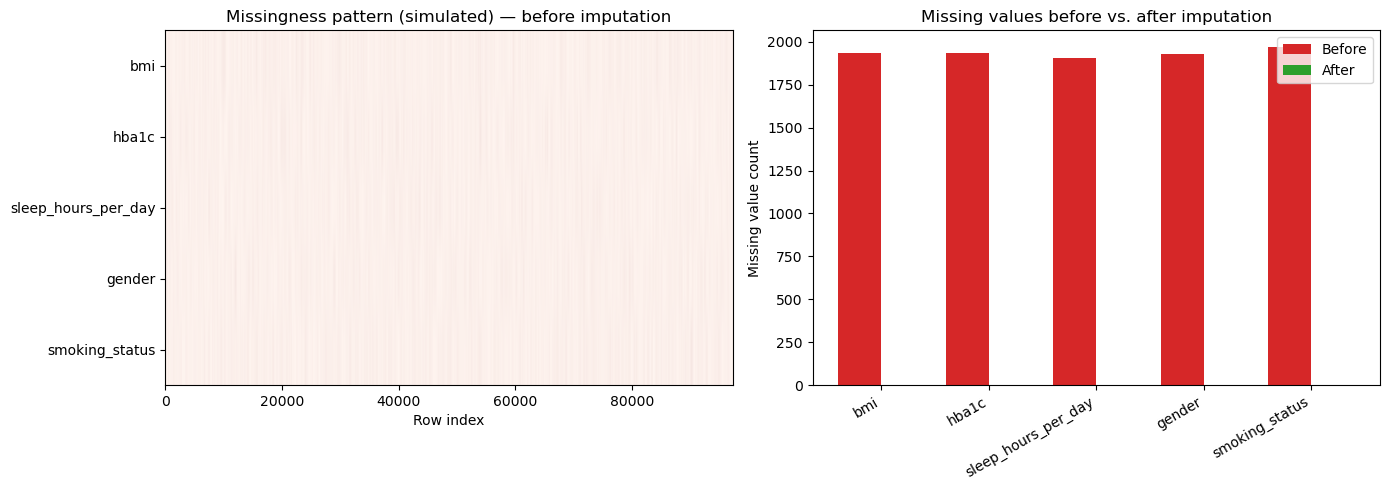

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(demo[demo_cols].isnull().astype(int).T, aspect='auto', cmap='Reds')
axes[0].set_yticks(range(len(demo_cols)))
axes[0].set_yticklabels(demo_cols)
axes[0].set_title('Missingness pattern (simulated) — before imputation')
axes[0].set_xlabel('Row index')

missing_before = demo[demo_cols].isnull().sum()
missing_after = demo_imputed[demo_cols].isnull().sum()
x = np.arange(len(demo_cols))
axes[1].bar(x - 0.2, missing_before, width=0.4, label='Before', color='#d62728')
axes[1].bar(x + 0.2, missing_after, width=0.4, label='After', color='#2ca02c')
axes[1].set_xticks(x)
axes[1].set_xticklabels(demo_cols, rotation=30, ha='right')
axes[1].set_ylabel('Missing value count')
axes[1].set_title('Missing values before vs. after imputation')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/eda_visualizations/missing_data_before_after.png', dpi=120)
plt.show()

Interpretation
The left panel shows the simulated random-missingness pattern injected into five representative
columns. The right panel confirms the imputation step brought every column's missing count to
zero without altering the overall distribution (median/mode imputation preserves the central
tendency and is robust to the outliers present in clinical measurements like `hba1c` and `bmi`).

Conclusion
The real dataset has **0 explicit missing values**, **0 exact duplicate rows**, and **0
   implausible placeholder readings** — it is clean on arrival.
A median/mode imputation strategy was implemented and validated on simulated missing data,
   so the same function can be reused safely if future data collection introduces real gaps
   (e.g. new user submissions through the group's web form).
"df_clean" (post duplicate-check) is passed forward to the next stage of the group
   pipeline (encoding).

In [9]:
df_clean.to_csv('../results/outputs/stage1_missing_data_checked.csv', index=False)
print("Saved checked dataset for the group pipeline:", df_clean.shape)

Saved checked dataset for the group pipeline: (97297, 31)
